# Convolutional Neural Networks (CNNs)

# 🧠 First, what problem are we solving?

With normal ML, data often looks like this:

| Hours Studied | Marks |
| ------------- | ----- |
| 2             | 40    |
| 5             | 80    |

But image data looks different.

A picture is not just one value.
It is made of **many tiny pixels**.

For example:

* a small grayscale image might be `28 x 28`
* that means **784 pixel values**
* a color image has even more values

So image data is huge.


# 🧠 Why CNN came

CNN came because images have **patterns** like:

* edges
* corners
* curves
* eyes
* ears
* shapes

A CNN is good at finding these patterns.

So instead of looking at the whole image in one big scary chunk, CNN looks at it **piece by piece**.

```text
CNN learns:
small patterns → bigger patterns → full object
```



# 📦 Main parts of CNN

A basic CNN usually has:

1. **Convolution layer**
2. **Activation function (ReLU)**
3. **Pooling layer**
4. **Flatten**
5. **Dense layer**
6. **Output layer**



#  Step 1 — Import libraries


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Mnist dataset ek esaa handwritettn digits images

In [2]:
# Mnist dataset is a dataset of handwritten digits, consisting of 60,000 training images and 10,000 test images. 
# Each image is a 28x28 pixel grayscale image, and the corresponding label is a digit from 0 to 9.

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

---

# 🧠 What this gives us

* `x_train` = training images
* `y_train` = correct answers for training images
* `x_test` = test images
* `y_test` = correct answers for test images

Example:

* image of handwritten `5`
* label = `5`

---



#  Step 3 — Check the shape of data



In [7]:
# Print shape of training data
print("x_train shape:", x_train.shape)

# Print shape of test data
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


You will usually see something like:

```python
x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
```

Meaning:

* `60000` training images
* each image is `28 x 28`
* `10000` test images

---

# Step 4 — Display one image

In [11]:
import matplotlib.pyplot as plt

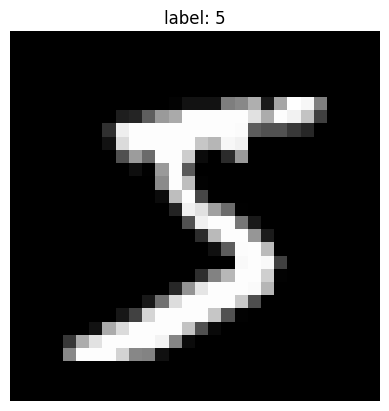

In [16]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"label: {y_train[0]}")
plt.axis('off')
plt.show()

In [17]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

# Step 5 — Normalize pixel values


In [18]:
# Normalize the pixel values to be between 0 and 1
x_train = x_train /255.0
x_test = x_test /255.0

In [19]:
x_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [20]:
x_train.shape

(60000, 28, 28)

In [21]:
x_train = x_train.reshape((60000, 28, 28,1))
x_test = x_test.reshape((10000, 28, 28,1))

In [22]:
x_train.shape

(60000, 28, 28, 1)

#  Step 7 — Build the CNN model


In [27]:
# Create a sequential model
# Sequential means layers will be added one after another in order
model = models.Sequential()

# First convolution layer
# 32 filters means the model will learn 32 small pattern detectors
# (3,3) means each filter looks at a 3x3 part of the image at a time
# activation="relu" helps the network learn non-linear patterns
# input_shape tells the model the size of each image
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))

# Pooling layer
# This reduces the image size and keeps important information
model.add(layers.MaxPooling2D((2, 2)))

# Second convolution layer
# Now the model learns more advanced patterns
model.add(layers.Conv2D(64, (3, 3), activation="relu"))

# Second pooling layer
model.add(layers.MaxPooling2D((2, 2)))

# fatten the output from the convolutional layers into a 1D vector

model.add(layers.Flatten())

# Fully connected layer with 64 neurons
model.add(layers.Dense(64, activation="relu"))

# Output layer with 10 neurons (one for each digit) and softmax activation
model.add(layers.Dense(10, activation="softmax"))

C:\Users\Edunet Foundation\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)



---

# 🧠 Super simple layer meaning

## 1) Convolution layer

This looks for tiny patterns like:

* edges
* curves
* small shapes

## 2) Pooling layer

This shrinks the information so the model keeps important things and removes extra detail.

## 3) Flatten

This turns image features into one long list.

## 4) Dense layer

This learns from those features.

## 5) Output layer

This tells which digit is most likely.

---


# Step 9 — Compile the model


In [31]:
model.compile(optimizer="adam", loss = "sparse_categorical_crossentropy", metrics=["accuracy"])

In [51]:
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9957 - loss: 0.0132 - val_accuracy: 0.9912 - val_loss: 0.0330
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9967 - loss: 0.0106 - val_accuracy: 0.9885 - val_loss: 0.0420
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9970 - loss: 0.0091 - val_accuracy: 0.9909 - val_loss: 0.0333
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9977 - loss: 0.0075 - val_accuracy: 0.9891 - val_loss: 0.0398
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9976 - loss: 0.0068 - val_accuracy: 0.9916 - val_loss: 0.0347


# Step 11 — Evaluate the model

In [35]:

# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Print final test accuracy
print("Test Accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9907 - loss: 0.0283
Test Accuracy: 0.9907000064849854
Test loss: 0.028251906856894493


# Step 12 — Predict one image


In [41]:
x_test[0]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [42]:
y_test[0]

np.uint8(7)

In [50]:
model.predict(x_test[:1]).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


np.int64(7)

# visualize

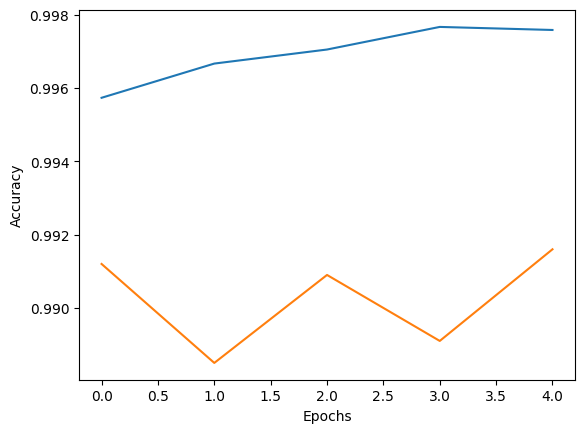

In [56]:
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()
